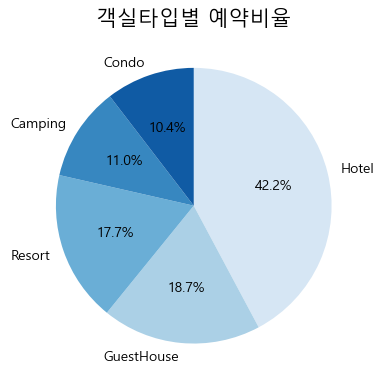

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick


# 출력옵션
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)
pd.set_option('display.unicode.east_asian_width',True)

# 호텔
hotel = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8')
hotelDf = pd.DataFrame(hotel)
# 객실
room = pd.read_csv('greenData/resort/room.csv', encoding='cp949')
roomDf = pd.DataFrame(room)
# 예약
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)
# 예약취소된건은 필터
reservationFilter = reservationDf[reservationDf['cancel'] != 1]
# 머지1
merged1 = pd.merge(hotelDf, roomDf, how="inner", on='h_code')
# 머지2
merged2 = pd.merge(merged1, reservationFilter, how="inner", on='r_code')

# 그룹묶어주기
type_count = merged2.groupby('type')['r_code'].count().reset_index()
type_count.columns = ['객실타입', '예약비율']

type_count['ratio'] = (type_count['예약비율'] / type_count['예약비율'].sum()) * 100
type_count = type_count.sort_values(by='예약비율', ascending=False)

plt.figure(figsize=(4,4))

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

colors = sns.color_palette("Blues", len(type_count))

plt.pie(
    type_count['예약비율'],
    labels=type_count['객실타입'],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={'edgecolor':'white', 'linewidth':0}  # 경계선
)

plt.title('객실타입별 예약비율', fontsize=15)

plt.tight_layout()
plt.show()

C:\Users\신댕\AppData\Local\Temp\ipykernel_24732\839423076.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


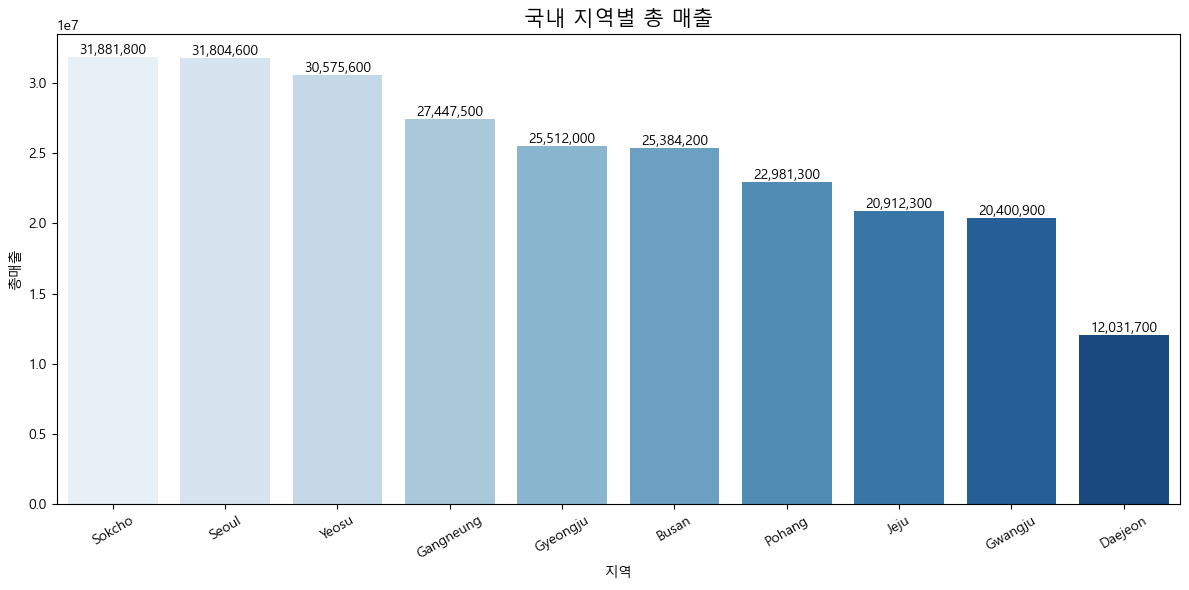

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# 출력옵션
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)
pd.set_option('display.unicode.east_asian_width',True)

# 호텔
hotel = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8')
hotelDf = pd.DataFrame(hotel)
# 객실
room = pd.read_csv('greenData/resort/room.csv', encoding='cp949')
roomDf = pd.DataFrame(room)
# 예약
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)
# 예약취소된건은 필터
reservationFilter = reservationDf[reservationDf['cancel'] != 1]
# 머지1
merged1 = pd.merge(hotelDf, roomDf, how="inner", on='h_code')
# 머지2
merged2 = pd.merge(merged1, reservationFilter, how="inner", on='r_code')

# 그룹묶어주기
korea_df = merged2[merged2['country'] == 'Korea']
city_sales = korea_df.groupby('city')['final_price'].sum().reset_index()
city_sales.columns = ['지역', '총매출']
city_sales = city_sales.sort_values(by='총매출', ascending=False)

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12,6))

colors = sns.color_palette("Blues", len(city_sales))

sns.barplot(
    data=city_sales,
    x='지역',
    y='총매출',
    palette=colors
)

# 값 표시 (천단위 콤마)
for i, v in enumerate(city_sales['총매출']):
    plt.text(i, v, f"{int(v):,}", ha='center', va='bottom', fontsize=10)

plt.title('국내 지역별 총 매출', fontsize=15)
plt.xlabel('지역')
plt.ylabel('총매출')


plt.xticks(rotation=30)  # 지역 많으면 기울이기
plt.ticklabel_format(style='sci', axis='y')  # 지수표기

#plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

C:\Users\신댕\AppData\Local\Temp\ipykernel_24732\2781389917.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


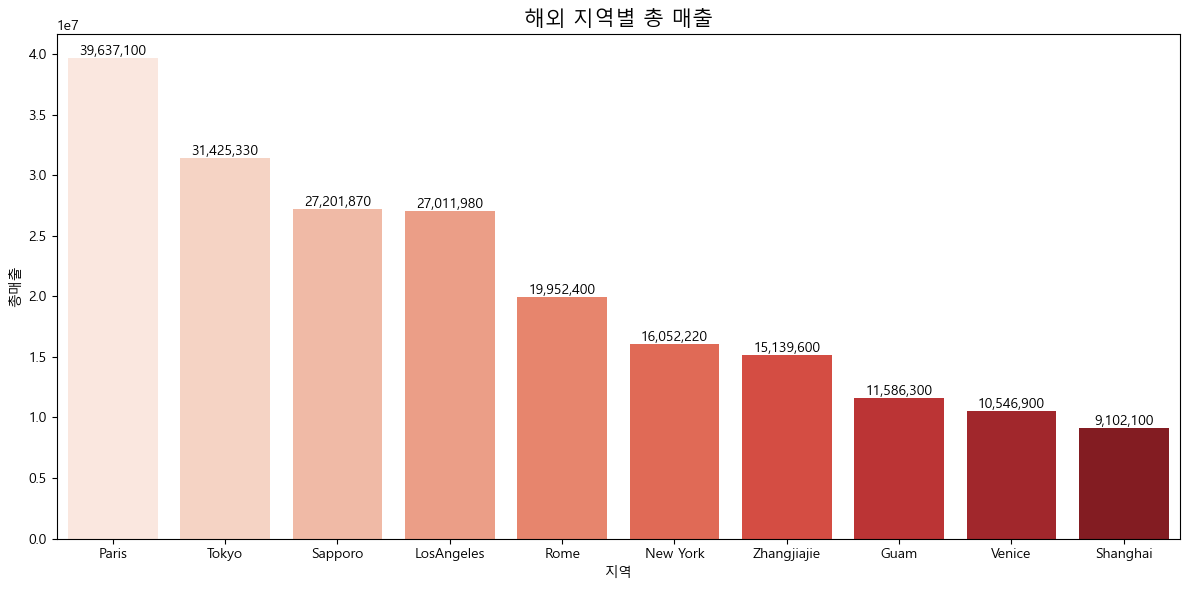

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 출력옵션
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)
pd.set_option('display.unicode.east_asian_width',True)

# 호텔
hotel = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8')
hotelDf = pd.DataFrame(hotel)
# 객실
room = pd.read_csv('greenData/resort/room.csv', encoding='cp949')
roomDf = pd.DataFrame(room)
# 예약
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)
# 예약취소된건은 필터
reservationFilter = reservationDf[reservationDf['cancel'] != 1]
# 머지1
merged1 = pd.merge(hotelDf, roomDf, how="inner", on='h_code')
# 머지2
merged2 = pd.merge(merged1, reservationFilter, how="inner", on='r_code')

# 그룹묶어주기
overseas_df = merged2[merged2['country'] != 'Korea']
city_sales_over = overseas_df.groupby('city')['final_price'].sum().reset_index()
city_sales_over.columns = ['지역', '총매출']
city_sales_over = city_sales_over.sort_values(by='총매출', ascending=False)

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12,6))

colors = sns.color_palette("Reds", len(city_sales_over))  # 해외니까 색 다르게

sns.barplot(
    data=city_sales_over,
    x='지역',
    y='총매출',
    palette=colors
)

# 값 표시
for i, v in enumerate(city_sales_over['총매출']):
    plt.text(i, v, f"{int(v):,}", ha='center', va='bottom', fontsize=10)

plt.title('해외 지역별 총 매출', fontsize=15)
plt.xlabel('지역')
plt.ylabel('총매출')

plt.ticklabel_format(style='sci', axis='y')  # 지수표기

plt.tight_layout()
plt.show()

C:\Users\신댕\AppData\Local\Temp\ipykernel_24732\464759657.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_count = merged2.groupby('가격대')['r_code'].count().reset_index()


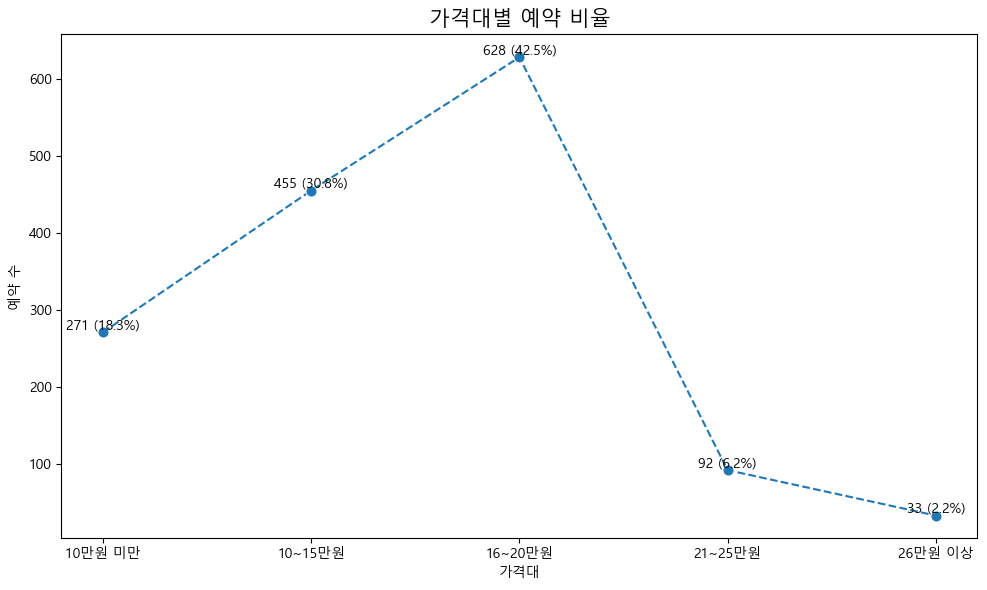

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 출력옵션
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)
pd.set_option('display.unicode.east_asian_width',True)

# 호텔
hotel = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8')
hotelDf = pd.DataFrame(hotel)
# 객실
room = pd.read_csv('greenData/resort/room.csv', encoding='cp949')
roomDf = pd.DataFrame(room)
# 예약
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)
# 예약취소된건은 필터
reservationFilter = reservationDf[reservationDf['cancel'] != 1]
# 머지1
merged1 = pd.merge(hotelDf, roomDf, how="inner", on='h_code')
# 머지2
merged2 = pd.merge(merged1, reservationFilter, how="inner", on='r_code')
merged2

#가격 구간 나누기
bins = [0, 100000, 150000, 200000, 250000, float('inf')]
labels = ['10만원 미만', '10~15만원', '16~20만원', '21~25만원', '26만원 이상']
merged2['가격대'] = pd.cut(merged2['price'], bins=bins, labels=labels, right=True)

# 가격대별 예약 수
price_count = merged2.groupby('가격대')['r_code'].count().reset_index()
price_count.columns = ['가격대', '예약수']

# 비율 추가
price_count['비율'] = (price_count['예약수'] / price_count['예약수'].sum()) * 100

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,6))

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.lineplot(
    data=price_count,
    x='가격대',
    y='예약수',
    marker='o',
    markersize=8,
    linestyle='--'
)
# 값 표시
for i, v in enumerate(price_count['예약수']):
    plt.text(i, v, f"{v} ({price_count['비율'].iloc[i]:.1f}%)",
             ha='center', va='bottom')

plt.title('가격대별 예약 비율', fontsize=15)
plt.xlabel('가격대')
plt.ylabel('예약 수')

plt.tight_layout()
plt.show()


C:\Users\신댕\AppData\Local\Temp\ipykernel_24732\1140697694.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_count = merged2.groupby('예약간격')['r_code'].count().reset_index()
C:\Users\신댕\AppData\Local\Temp\ipykernel_24732\1140697694.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


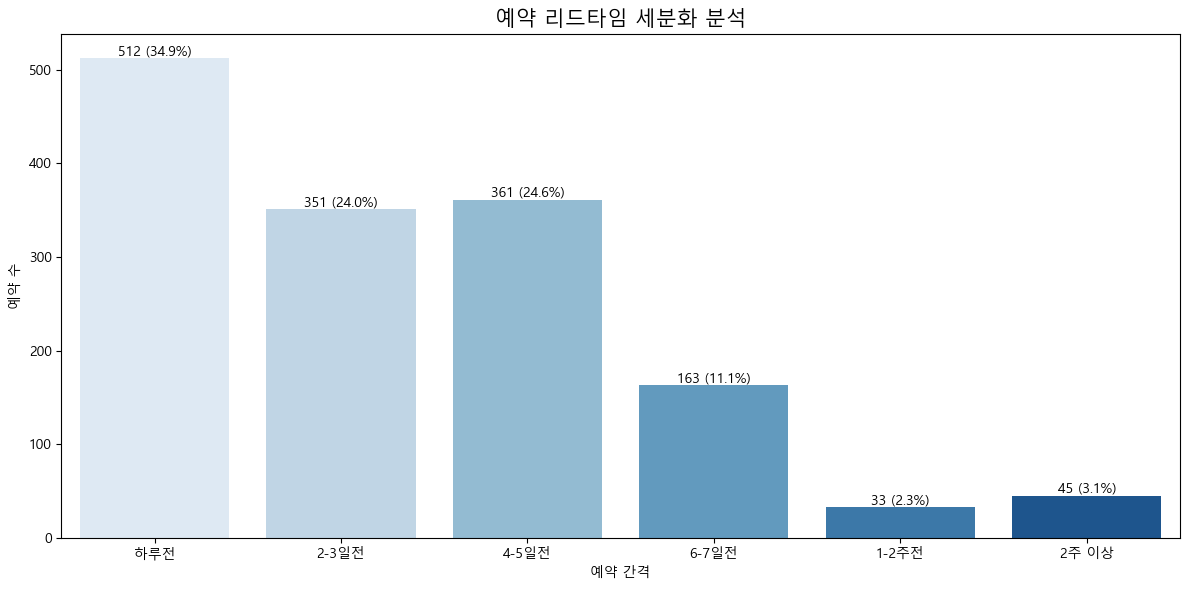

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 출력옵션
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)
pd.set_option('display.unicode.east_asian_width',True)

# 호텔
hotel = pd.read_csv('greenData/resort/hotel.csv', encoding='utf-8')
hotelDf = pd.DataFrame(hotel)
# 객실
room = pd.read_csv('greenData/resort/room.csv', encoding='cp949')
roomDf = pd.DataFrame(room)
# 예약
reservation = pd.read_csv('greenData/resort/reservation.csv', encoding='cp949')
reservationDf = pd.DataFrame(reservation)
# 예약취소된건은 필터
reservationFilter = reservationDf[reservationDf['cancel'] != 1]
# 머지1
merged1 = pd.merge(hotelDf, roomDf, how="inner", on='h_code')
# 머지2
merged2 = pd.merge(merged1, reservationFilter, how="inner", on='r_code')
# 날짜 타입 변환
merged2['reserved_at'] = pd.to_datetime(merged2['reserved_at'])
merged2['check_in_date'] = pd.to_datetime(merged2['check_in_date'])
# 날짜 차이 계산 (일 단위)
merged2['lead_days'] = (merged2['check_in_date'] - merged2['reserved_at']).dt.days
# 구간 나누기
bins = [-1, 1, 3, 5, 7, 14, float('inf')]
labels = ['하루전', '2-3일전', '4-5일전', '6-7일전', '1-2주전', '2주 이상']

merged2['예약간격'] = pd.cut(
    merged2['lead_days'],
    bins=bins,
    labels=labels,
    right=True  # 오른쪽 포함
)

#집계
lead_count = merged2.groupby('예약간격')['r_code'].count().reset_index()
lead_count.columns = ['예약간격', '예약수']

lead_count['비율'] = (lead_count['예약수'] / lead_count['예약수'].sum()) * 100

#순서 정렬
lead_count['예약간격'] = pd.Categorical(
    lead_count['예약간격'],
    categories=labels,
    ordered=True
)

lead_count = lead_count.sort_values('예약간격')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12,6))

colors = sns.color_palette("Blues", len(lead_count))

sns.barplot(
    data=lead_count,
    x='예약간격',
    y='예약수',
    palette=colors
)

for i, v in enumerate(lead_count['예약수']):
    plt.text(i, v, f"{v} ({lead_count['비율'].iloc[i]:.1f}%)",
             ha='center', va='bottom')

plt.title('예약 리드타임 세분화 분석', fontsize=15)
plt.xlabel('예약 간격')
plt.ylabel('예약 수')

plt.tight_layout()
plt.show()